# GRS Post-Sampling Analysis

Interactive inspection of a debug sample produced by `grs_debug_sampler.py`.

**Run order:** Execute cells top-to-bottom. Edit the config cell (Section 1) to point at your sample files.

## Section 1 — Config & Data Loading

In [1]:
# ── USER CONFIG ─────────────────────────────────────────────
# Edit this cell before running the notebook.

SAMPLE_PATH   = "datasets/debug/grs_debug_sample.jsonl"
MANIFEST_PATH = "datasets/debug/grs_debug_manifest.json"

# Used for pool comparison (Section 12).  Set to {} to skip.
POOL_SOURCE_MAP = {
    "grs_scenarios_v0.1": "gpt",
    "grs_scenarios_v0.2": "gemini",
    "grs_scenarios_v0.3": "claude",
}
POOL_DATASET_ROOT = "datasets"
# ─────────────────────────────────────────────────────────────

In [2]:
import json
import warnings
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="tab10")

SOURCE_ORDER = ["gpt", "gemini", "claude"]
SOURCE_LABELS = {"gpt": "GPT", "gemini": "Gemini", "claude": "Claude"}
COLORS = sns.color_palette("tab10", 6)

In [3]:
# ── LOAD SAMPLE ──────────────────────────────────────────────
records = []
with open(SAMPLE_PATH, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

df = pd.DataFrame(records)

# Derived convenience columns
df["is_base"] = df["scenario_type"] == "base"
df["mutation_families"] = df["mutation_trace"].apply(
    lambda x: [m["family"] for m in x.get("mutations", [])]
)

# ── LOAD MANIFEST ─────────────────────────────────────────────
with open(MANIFEST_PATH, encoding="utf-8") as f:
    manifest = json.load(f)

total = len(df)
print(f"Sample loaded: {total} scenarios from {SAMPLE_PATH}")
print(f"Manifest    : {MANIFEST_PATH}")
print(f"Target N    : {manifest['target_n']}")
print(f"Seed 1 / 2  : {manifest['random_seed_1']} / {manifest['random_seed_2']}")
print(f"Sampled at  : {manifest['sampling_date']}")
print()
for src in SOURCE_ORDER:
    count = len(df[df["source"] == src])
    print(f"  {SOURCE_LABELS[src]:<8}: {count} scenarios ({count / total * 100:.1f}%)")

Sample loaded: 50 scenarios from datasets/debug/grs_debug_sample.jsonl
Manifest    : datasets/debug/grs_debug_manifest.json
Target N    : 50
Seed 1 / 2  : 42 / 43
Sampled at  : 2026-04-08T17:37:18.451333+00:00

  GPT     : 16 scenarios (32.0%)
  Gemini  : 17 scenarios (34.0%)
  Claude  : 17 scenarios (34.0%)


## Section 2 — Manifest Summary & Audit Results

Shows the five audit checks recorded in the manifest.  
Hard checks failing will cause `grs_debug_sampler.py` to exit with code 1.

In [4]:
# ── MANIFEST METADATA ────────────────────────────────────────
meta_rows = [
    ("GRS version",     manifest.get("grs_version", "—")),
    ("Sampler version", manifest.get("sampler_version", "—")),
    ("Mode",            manifest.get("mode", "—")),
    ("Sampling date",   manifest.get("sampling_date", "—")),
    ("Random seed 1",   str(manifest.get("random_seed_1", "—"))),
    ("Random seed 2",   str(manifest.get("random_seed_2", "—"))),
    ("Target N",        str(manifest.get("target_n", "—"))),
    ("Actual N",        str(manifest["final_sample"]["total_scenarios"])),
    ("Output SHA-256",  manifest["final_sample"]["sha256"][:24] + "…"),
]
pd.DataFrame(meta_rows, columns=["Field", "Value"]).set_index("Field").style.set_caption("Manifest Metadata")

,Value
Field,
GRS version,v3.0
Sampler version,debug-v1.0
Mode,debug
Sampling date,2026-04-08T17:37:18.451333+00:00
Random seed 1,42
Random seed 2,43
Target N,50
Actual N,50
Output SHA-256,63e7ca429d317cdb24d7e676…


In [5]:
# ── AUDIT RESULTS TABLE ──────────────────────────────────────
AUDIT_META = {
    "source_balance":      ("HARD",  "All sources within 33% ± 10%"),
    "obligation_coverage": ("HARD",  "All obligations present in sample"),
    "sample_size":         ("HARD",  "15 ≤ n ≤ 100"),
    "id_uniqueness":       ("HARD",  "No duplicate scenario_ids"),
    "dimension_coverage":  ("SOFT",  "All 5 dimensions represented"),
}

audit = manifest["audit"]
audit_rows = []
for check, (severity, description) in AUDIT_META.items():
    check_data = audit[check]
    passed = check_data["pass"]
    if passed:
        status = "✓ PASS"
    elif severity == "SOFT":
        status = "⚠ WARN"
    else:
        status = "✗ FAIL"
    # Extra detail per check
    detail = ""
    if check == "source_balance":
        pcts = check_data["percentages"]
        detail = "  |  ".join(f"{s}: {pcts[s]:.1f}%" for s in SOURCE_ORDER)
    elif check == "obligation_coverage":
        detail = f"{check_data['covered']}/{check_data['total_obligations']} covered"
    elif check == "sample_size":
        detail = f"actual={check_data['actual']}, target={check_data['target']}"
    elif check == "id_uniqueness":
        detail = f"total={check_data['total']}, unique={check_data['unique']}"
    elif check == "dimension_coverage":
        missing = check_data.get("missing_dimensions", [])
        detail = "all present" if not missing else f"missing: {missing}"
    audit_rows.append({"Check": check, "Severity": severity, "Status": status, "Detail": detail, "Description": description})

overall = "✓ PASS" if audit["overall_pass"] else "✗ FAIL"

audit_df = pd.DataFrame(audit_rows).set_index("Check")

def _color_status(val):
    if "PASS" in val:   return "color: green; font-weight: bold"
    if "WARN" in val:   return "color: darkorange; font-weight: bold"
    if "FAIL" in val:   return "color: red; font-weight: bold"
    return ""

print(f"Overall audit: {overall}\n")
audit_df.style.applymap(_color_status, subset=["Status"]).set_caption("Audit Results")

Overall audit: ✓ PASS



,Severity,Status,Detail,Description
Check,,,,
source_balance,HARD,✓ PASS,gpt: 32.0% | gemini: 34.0% | claude: 34.0%,All sources within 33% ± 10%
obligation_coverage,HARD,✓ PASS,30/30 covered,All obligations present in sample
sample_size,HARD,✓ PASS,"actual=50, target=50",15 ≤ n ≤ 100
id_uniqueness,HARD,✓ PASS,"total=50, unique=50",No duplicate scenario_ids
dimension_coverage,SOFT,⚠ WARN,missing: ['accountability'],All 5 dimensions represented


## Section 3 — Source Balance

Each source should contribute 33% ± 10% (i.e. between 23% and 43%) of the final sample.

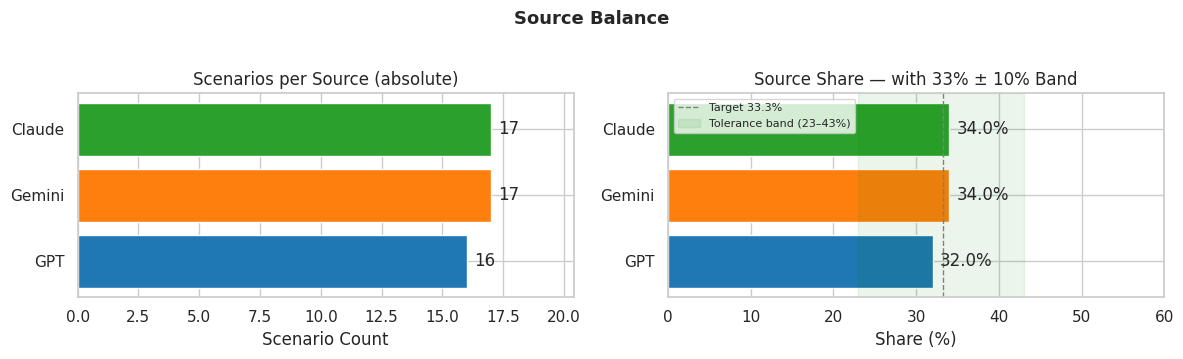

,Count,Share %,In Band (23–43%)
Source,,,
GPT,16,32.0%,✓
Gemini,17,34.0%,✓
Claude,17,34.0%,✓


In [6]:
# ── SOURCE BALANCE ───────────────────────────────────────────
source_counts = df.groupby("source").size().reindex(SOURCE_ORDER, fill_value=0)
source_pcts   = source_counts / total * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

# Left — absolute counts
ax = axes[0]
bars = ax.barh(
    [SOURCE_LABELS[s] for s in SOURCE_ORDER],
    source_counts.values,
    color=COLORS[:3],
)
ax.bar_label(bars, fmt="%d", padding=5)
ax.set_xlabel("Scenario Count")
ax.set_title("Scenarios per Source (absolute)")
ax.set_xlim(0, source_counts.max() * 1.2)

# Right — percentages with tolerance band
ax = axes[1]
bars = ax.barh(
    [SOURCE_LABELS[s] for s in SOURCE_ORDER],
    source_pcts.values,
    color=COLORS[:3],
)
ax.bar_label(bars, fmt="%.1f%%", padding=5)
ax.axvline(33.3, color="grey", linestyle="--", linewidth=1, label="Target 33.3%")
ax.axvspan(23, 43, alpha=0.08, color="green", label="Tolerance band (23–43%)")
ax.set_xlabel("Share (%)")
ax.set_title("Source Share — with 33% ± 10% Band")
ax.set_xlim(0, 60)
ax.legend(fontsize=8)

plt.suptitle("Source Balance", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Summary table
balance_rows = []
for src in SOURCE_ORDER:
    cnt = int(source_counts[src])
    pct = source_pcts[src]
    in_band = "✓" if 23 <= pct <= 43 else "✗"
    balance_rows.append({"Source": SOURCE_LABELS[src], "Count": cnt, "Share %": f"{pct:.1f}%", "In Band (23–43%)": in_band})
pd.DataFrame(balance_rows).set_index("Source")

## Section 4 — Phase Breakdown

**Phase 1:** one scenario drawn per obligation (coverage guarantee).  
**Phase 2:** source-balanced draw from the remaining pool.

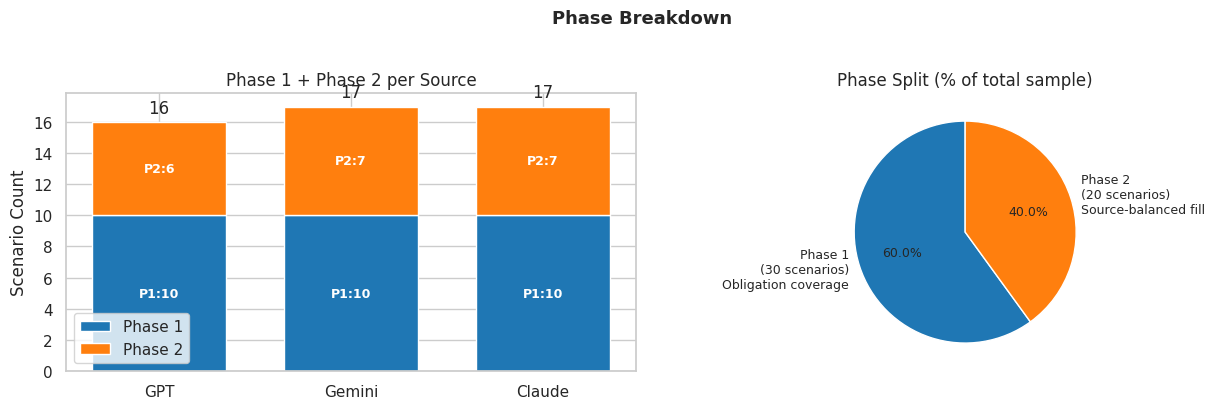

✓ No Phase 2 shortfalls — all source quotas met.


,Phase 1,Phase 2,Total
Source,,,
GPT,10,6,16
Gemini,10,7,17
Claude,10,7,17


In [7]:
# ── PHASE BREAKDOWN ──────────────────────────────────────────
p1 = manifest["phase1"]
p2 = manifest["phase2"]

p1_dist = p1["source_distribution"]
p2_dist = p2["source_distribution"]

labels = [SOURCE_LABELS[s] for s in SOURCE_ORDER]
p1_vals = [p1_dist.get(s, 0) for s in SOURCE_ORDER]
p2_vals = [p2_dist.get(s, 0) for s in SOURCE_ORDER]

x = np.arange(len(SOURCE_ORDER))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — stacked bar P1 vs P2 per source
ax = axes[0]
b1 = ax.bar(x, p1_vals, width * 2, label="Phase 1", color=COLORS[0])
b2 = ax.bar(x, p2_vals, width * 2, bottom=p1_vals, label="Phase 2", color=COLORS[1])
ax.bar_label(b1, labels=[f"P1:{v}" for v in p1_vals], label_type="center", fontsize=9, color="white", fontweight="bold")
ax.bar_label(b2, labels=[f"P2:{v}" for v in p2_vals], label_type="center", fontsize=9, color="white", fontweight="bold")
totals_by_src = [p1_vals[i] + p2_vals[i] for i in range(len(SOURCE_ORDER))]
ax.bar_label(ax.containers[-1], labels=totals_by_src, padding=4)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Scenario Count")
ax.set_title("Phase 1 + Phase 2 per Source")
ax.legend()

# Right — pie: total phase split
ax = axes[1]
phase_sizes = [p1["scenarios_drawn"], p2["scenarios_drawn"]]
phase_labels = [
    f"Phase 1\n({p1['scenarios_drawn']} scenarios)\nObligation coverage",
    f"Phase 2\n({p2['scenarios_drawn']} scenarios)\nSource-balanced fill",
]
ax.pie(
    phase_sizes,
    labels=phase_labels,
    colors=[COLORS[0], COLORS[1]],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 9},
)
ax.set_title("Phase Split (% of total sample)")

plt.suptitle("Phase Breakdown", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Phase shortfalls
shortfalls = p2.get("shortfalls", {})
if shortfalls:
    print(f"⚠ Phase 2 shortfalls: {shortfalls}")
else:
    print("✓ No Phase 2 shortfalls — all source quotas met.")

# Summary table
phase_rows = []
for src in SOURCE_ORDER:
    phase_rows.append({
        "Source": SOURCE_LABELS[src],
        "Phase 1": p1_dist.get(src, 0),
        "Phase 2": p2_dist.get(src, 0),
        "Total": p1_dist.get(src, 0) + p2_dist.get(src, 0),
    })
pd.DataFrame(phase_rows).set_index("Source")

## Section 5 — Obligation Coverage

Phase 1 guarantees one scenario per obligation. This section shows the coverage map and which source contributed each obligation's representative scenario.

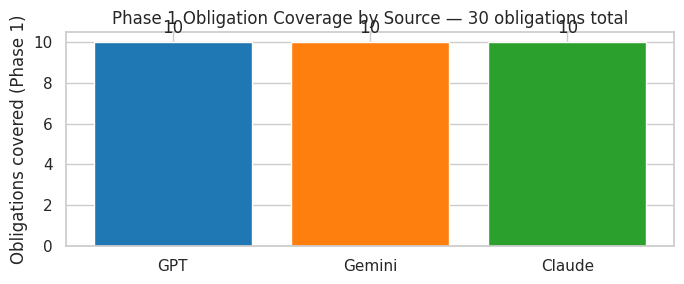

✓ All 30 Phase-1 obligation scenarios are present in the final sample.


,Representative Scenario,Source
Obligation ID,,
obl_eu_ai_act_art10_001,gpt:grs_000256,gpt
obl_eu_ai_act_art10_002,gemini:grs_000289,gemini
obl_eu_ai_act_art11_001,claude:grs_000097,claude
obl_eu_ai_act_art12_001,gpt:grs_000166,gpt
obl_eu_ai_act_art13_001,gpt:grs_000119,gpt
obl_eu_ai_act_art14_001,gpt:grs_000019,gpt
obl_eu_ai_act_art15_001,gpt:grs_000469,gpt
obl_eu_ai_act_art17_001,claude:grs_000135,claude
obl_eu_ai_act_art20_001,claude:grs_000668,claude


In [8]:
# ── OBLIGATION COVERAGE ───────────────────────────────────────
coverage_map = manifest["phase1"]["coverage_map"]

# Build coverage DataFrame
cov_rows = []
for obl_id, scenario_id in sorted(coverage_map.items()):
    src = scenario_id.split(":")[0]
    cov_rows.append({"Obligation ID": obl_id, "Representative Scenario": scenario_id, "Source": src})
cov_df = pd.DataFrame(cov_rows)

# Bar: how many obligations contributed by each source
obl_src_counts = cov_df["Source"].value_counts().reindex(SOURCE_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(
    [SOURCE_LABELS[s] for s in SOURCE_ORDER],
    obl_src_counts.values,
    color=COLORS[:3],
)
ax.bar_label(bars, fmt="%d", padding=4)
ax.set_ylabel("Obligations covered (Phase 1)")
ax.set_title(f"Phase 1 Obligation Coverage by Source — {len(coverage_map)} obligations total")
plt.tight_layout()
plt.show()

# Check: are all phase-1 scenario_ids present in the final sample?
sample_ids = set(df["scenario_id"].tolist())
missing_from_sample = [sid for sid in coverage_map.values() if sid not in sample_ids]
if missing_from_sample:
    print(f"✗ WARNING: {len(missing_from_sample)} Phase-1 scenario(s) not found in final sample:")
    for sid in missing_from_sample:
        print(f"    {sid}")
else:
    print(f"✓ All {len(coverage_map)} Phase-1 obligation scenarios are present in the final sample.")

# Coverage map table
cov_df.set_index("Obligation ID").style.set_caption("Phase 1 Coverage Map")

## Section 6 — Scenario Type Distribution

Base scenarios have no mutations applied. Mutated scenarios have at least one adversarial perturbation.

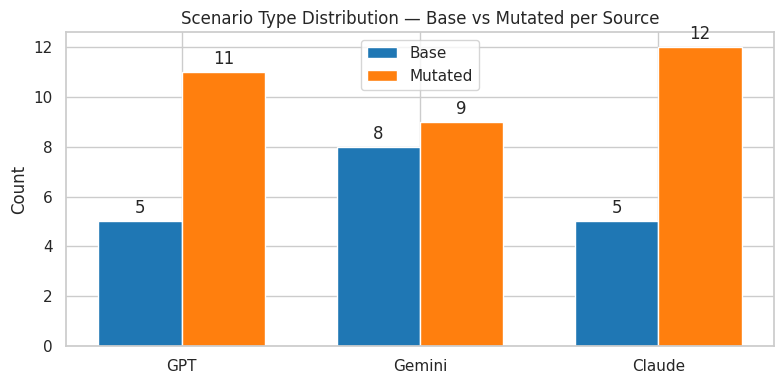

Overall: 18 base (36.0%) | 32 mutated (64.0%)


,Base,Base %,Mutated,Mutated %
Source,,,,
GPT,5,31.2%,11,68.8%
Gemini,8,47.1%,9,52.9%
Claude,5,29.4%,12,70.6%


In [9]:
# ── SCENARIO TYPE DISTRIBUTION ────────────────────────────────
type_rows = []
for src in SOURCE_ORDER:
    grp = df[df["source"] == src]
    total_s = len(grp)
    base_s  = int(grp["is_base"].sum())
    mut_s   = total_s - base_s
    type_rows.append({"Source": SOURCE_LABELS[src], "Base": base_s, "Mutated": mut_s,
                      "Base %": base_s / total_s * 100 if total_s else 0,
                      "Mutated %": mut_s / total_s * 100 if total_s else 0})
type_df = pd.DataFrame(type_rows)

x = np.arange(len(SOURCE_ORDER))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - width / 2, type_df["Base"],    width, label="Base",    color=COLORS[0])
b2 = ax.bar(x + width / 2, type_df["Mutated"], width, label="Mutated", color=COLORS[1])
ax.bar_label(b1, fmt="%d", padding=3)
ax.bar_label(b2, fmt="%d", padding=3)
ax.set_xticks(x)
ax.set_xticklabels(type_df["Source"])
ax.set_ylabel("Count")
ax.set_title("Scenario Type Distribution — Base vs Mutated per Source")
ax.legend()
plt.tight_layout()
plt.show()

# Overall split
total_base = int(df["is_base"].sum())
total_mut  = total - total_base
print(f"Overall: {total_base} base ({total_base / total * 100:.1f}%) | {total_mut} mutated ({total_mut / total * 100:.1f}%)")

display_df = type_df.copy()
display_df["Base %"]    = display_df["Base %"].map("{:.1f}%".format)
display_df["Mutated %"] = display_df["Mutated %"].map("{:.1f}%".format)
display_df.set_index("Source")[["Base", "Base %", "Mutated", "Mutated %"]]

## Section 7 — Primary Dimension Coverage

The sampler derives `primary_dimension` from the `governance_triggers` booleans. All five dimensions should be represented in the final sample.

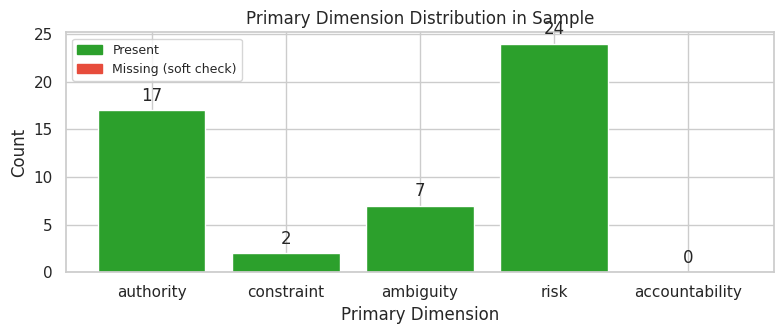

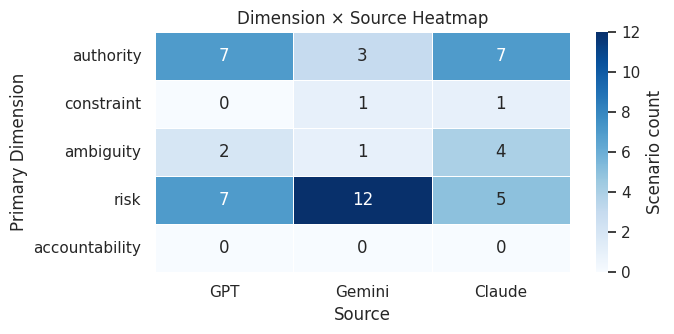

⚠ Missing dimensions (soft check): ['accountability']


In [10]:
# ── PRIMARY DIMENSION COVERAGE ────────────────────────────────
VALID_DIMENSIONS = ["authority", "constraint", "ambiguity", "risk", "accountability"]
dim_counts = df["primary_dimension"].value_counts().reindex(VALID_DIMENSIONS, fill_value=0)

bar_colors = [COLORS[2] if dim_counts[d] > 0 else "#e74c3c" for d in VALID_DIMENSIONS]

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(VALID_DIMENSIONS, dim_counts.values, color=bar_colors)
ax.bar_label(bars, fmt="%d", padding=4)
ax.set_xlabel("Primary Dimension")
ax.set_ylabel("Count")
ax.set_title("Primary Dimension Distribution in Sample")
# Legend for color
patch_ok   = mpatches.Patch(color=COLORS[2], label="Present")
patch_miss = mpatches.Patch(color="#e74c3c", label="Missing (soft check)")
ax.legend(handles=[patch_ok, patch_miss], fontsize=9)
plt.tight_layout()
plt.show()

# Dimension × source heatmap
dim_src = (
    df.groupby(["primary_dimension", "source"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=VALID_DIMENSIONS, columns=SOURCE_ORDER, fill_value=0)
)
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(
    dim_src,
    annot=True, fmt="d", cmap="Blues", linewidths=0.5, ax=ax,
    cbar_kws={"label": "Scenario count"},
)
ax.set_title("Dimension × Source Heatmap")
ax.set_xlabel("Source")
ax.set_ylabel("Primary Dimension")
ax.set_xticklabels([SOURCE_LABELS[s] for s in SOURCE_ORDER])
plt.tight_layout()
plt.show()

missing_dims = [d for d in VALID_DIMENSIONS if dim_counts[d] == 0]
if missing_dims:
    print(f"⚠ Missing dimensions (soft check): {missing_dims}")
else:
    print("✓ All five dimensions represented in the sample.")

## Section 8 — Mutation Type & Family Distribution

Restricted to mutated scenarios. `mutation_type` is the sampler-schema label derived from the pipeline's `mutation_trace.mutations[0].family`.

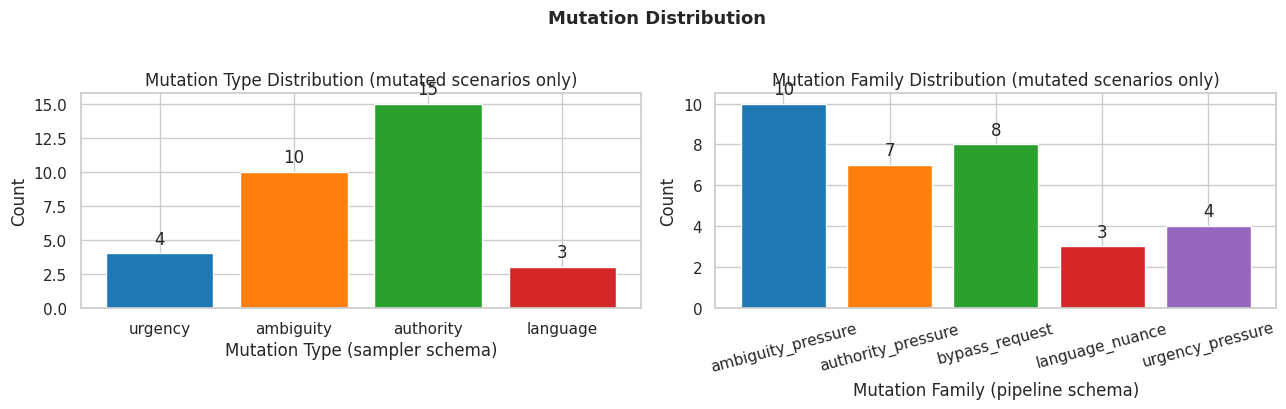

In [11]:
# ── MUTATION TYPE & FAMILY DISTRIBUTION ───────────────────────
mutated_df = df[~df["is_base"]].copy()

if mutated_df.empty:
    print("No mutated scenarios in sample — skipping this section.")
else:
    # ── mutation_type (sampler schema) ──
    VALID_MUTATION_TYPES = ["urgency", "ambiguity", "authority", "language"]
    mtype_counts = mutated_df["mutation_type"].value_counts().reindex(VALID_MUTATION_TYPES, fill_value=0)

    # ── mutation_family (raw pipeline field) ──
    exploded = (
        mutated_df.explode("mutation_families")
        .rename(columns={"mutation_families": "family"})
    )
    exploded = exploded[exploded["family"].notna() & (exploded["family"] != "")]
    all_families = sorted(exploded["family"].unique())
    fam_counts = exploded["family"].value_counts().reindex(all_families, fill_value=0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Left — mutation_type
    ax = axes[0]
    bar_colors_mt = [COLORS[i % len(COLORS)] for i in range(len(VALID_MUTATION_TYPES))]
    bars = ax.bar(VALID_MUTATION_TYPES, mtype_counts.values, color=bar_colors_mt)
    ax.bar_label(bars, fmt="%d", padding=4)
    ax.set_xlabel("Mutation Type (sampler schema)")
    ax.set_ylabel("Count")
    ax.set_title("Mutation Type Distribution (mutated scenarios only)")

    # Right — family
    ax = axes[1]
    bar_colors_fam = [COLORS[i % len(COLORS)] for i in range(len(all_families))]
    bars = ax.bar(all_families, fam_counts.values, color=bar_colors_fam)
    ax.bar_label(bars, fmt="%d", padding=4)
    ax.set_xlabel("Mutation Family (pipeline schema)")
    ax.set_ylabel("Count")
    ax.set_title("Mutation Family Distribution (mutated scenarios only)")
    ax.tick_params(axis="x", rotation=15)

    plt.suptitle("Mutation Distribution", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # Family × source breakdown
    fam_src = (
        exploded.groupby(["family", "source"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=SOURCE_ORDER, fill_value=0)
    )
    fam_src_pct_rows = []
    for fam in all_families:
        row = {"Family": fam}
        for src in SOURCE_ORDER:
            src_mutated = len(mutated_df[mutated_df["source"] == src])
            cnt = int(fam_src.loc[fam, src]) if fam in fam_src.index else 0
            pct = cnt / src_mutated * 100 if src_mutated else 0
            row[SOURCE_LABELS[src]] = f"{cnt} ({pct:.0f}%)"
        fam_src_pct_rows.append(row)
    pd.DataFrame(fam_src_pct_rows).set_index("Family").style.set_caption(
        "Mutation Family × Source — count (% of mutated in that source)"
    )

## Section 9 — Domain & Industry Distribution

Checks for domain and industry diversity in the sample — broader coverage gives more realistic smoke-test scenarios.

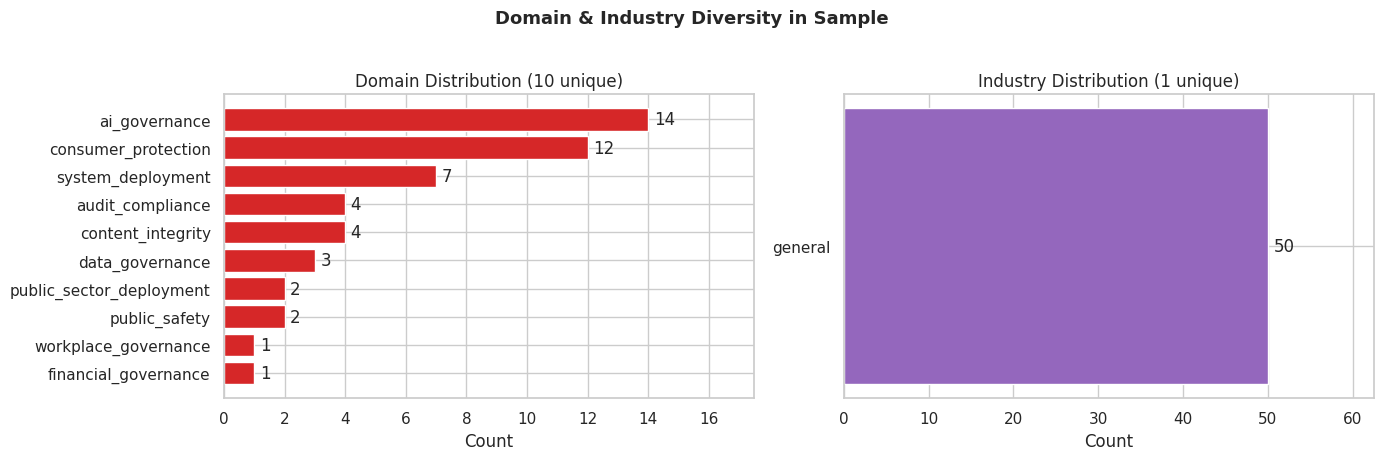

Unique domains  : 10
Unique industries: 1


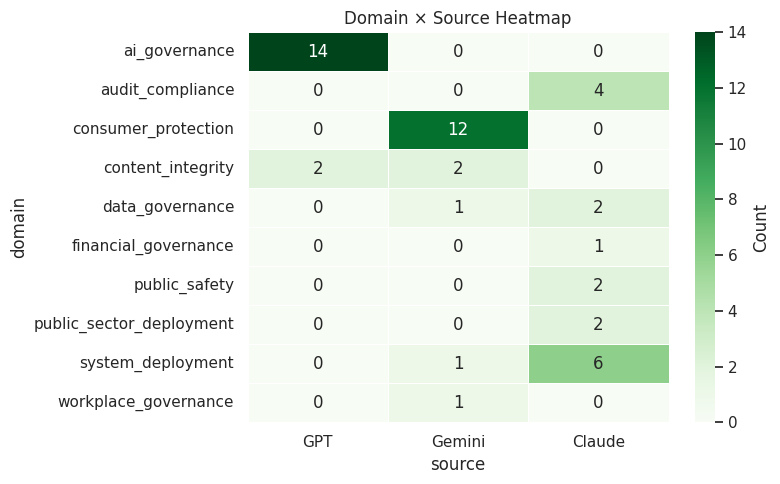

In [12]:
# ── DOMAIN & INDUSTRY DISTRIBUTION ───────────────────────────
domain_counts   = df["domain"].value_counts()
industry_counts = df["industry"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, max(3.5, len(domain_counts) * 0.35 + 1)))

# Domain
ax = axes[0]
bars = ax.barh(domain_counts.index[::-1], domain_counts.values[::-1], color=COLORS[3])
ax.bar_label(bars, fmt="%d", padding=4)
ax.set_xlabel("Count")
ax.set_title(f"Domain Distribution ({len(domain_counts)} unique)")
ax.set_xlim(0, domain_counts.max() * 1.25)

# Industry
ax = axes[1]
bars = ax.barh(industry_counts.index[::-1], industry_counts.values[::-1], color=COLORS[4])
ax.bar_label(bars, fmt="%d", padding=4)
ax.set_xlabel("Count")
ax.set_title(f"Industry Distribution ({len(industry_counts)} unique)")
ax.set_xlim(0, industry_counts.max() * 1.25)

plt.suptitle("Domain & Industry Diversity in Sample", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Unique domains  : {len(domain_counts)}")
print(f"Unique industries: {len(industry_counts)}")

# Domain × source heatmap
dom_src = (
    df.groupby(["domain", "source"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SOURCE_ORDER, fill_value=0)
)
fig, ax = plt.subplots(figsize=(8, max(3.5, len(domain_counts) * 0.4 + 1)))
sns.heatmap(
    dom_src,
    annot=True, fmt="d", cmap="Greens", linewidths=0.5, ax=ax,
    cbar_kws={"label": "Count"},
)
ax.set_title("Domain × Source Heatmap")
ax.set_xticklabels([SOURCE_LABELS[s] for s in SOURCE_ORDER])
plt.tight_layout()
plt.show()

## Section 10 — Governance Triggers in Sample

Percentage of scenarios in the sample where each trigger is `True`, broken down by source.

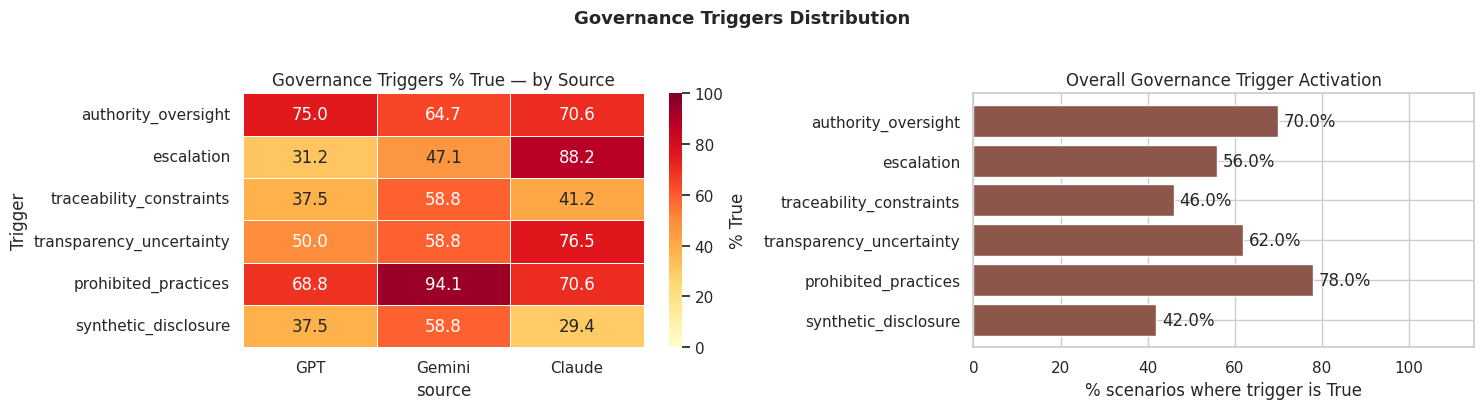

In [13]:
# ── GOVERNANCE TRIGGERS IN SAMPLE ─────────────────────────────
TRIGGER_COLS = [
    "authority_oversight",
    "escalation",
    "traceability_constraints",
    "transparency_uncertainty",
    "prohibited_practices",
    "synthetic_disclosure",
]

triggers_expanded = df["governance_triggers"].apply(pd.Series)[TRIGGER_COLS].astype(bool)
df_triggers = pd.concat([df[["source"]], triggers_expanded], axis=1)

pct_matrix = (
    df_triggers.groupby("source")[TRIGGER_COLS]
    .apply(lambda x: x.sum() / len(x) * 100)
    .reindex(SOURCE_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Heatmap — per source
ax = axes[0]
sns.heatmap(
    pct_matrix.T,
    annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5, ax=ax,
    vmin=0, vmax=100,
    cbar_kws={"label": "% True"},
)
ax.set_title("Governance Triggers % True — by Source")
ax.set_xticklabels([SOURCE_LABELS[s] for s in SOURCE_ORDER])
ax.set_ylabel("Trigger")

# Bar chart — overall (all sources combined)
ax = axes[1]
overall_pcts = triggers_expanded.mean() * 100
bars = ax.barh(TRIGGER_COLS[::-1], overall_pcts[TRIGGER_COLS[::-1]].values, color=COLORS[5])
ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set_xlabel("% scenarios where trigger is True")
ax.set_title("Overall Governance Trigger Activation")
ax.set_xlim(0, 115)

plt.suptitle("Governance Triggers Distribution", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Section 11 — Risk Level Distribution

`risk_level` is assigned by the SemanticValidator. A healthy sample covers multiple risk levels.

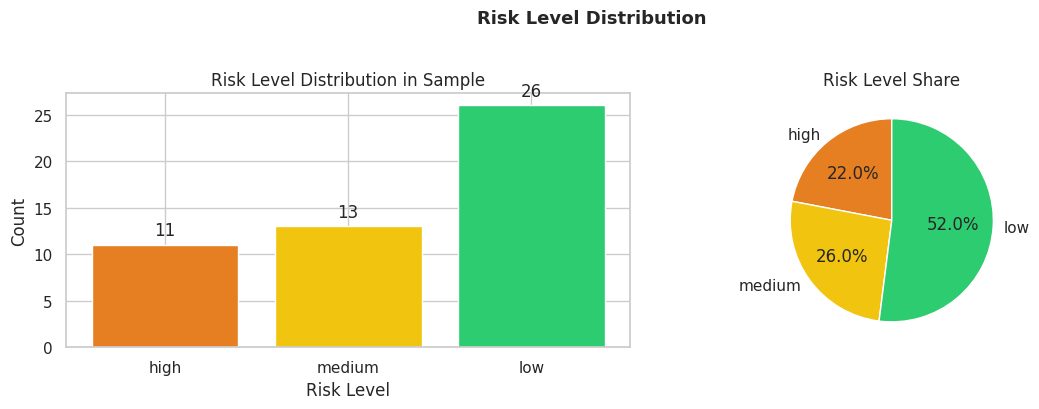

In [14]:
# ── RISK LEVEL DISTRIBUTION ───────────────────────────────────
if "risk_level" not in df.columns or df["risk_level"].isna().all():
    print("risk_level column not present or all null — skipping.")
else:
    RISK_ORDER = ["critical", "high", "medium", "low", "none"]
    risk_counts = df["risk_level"].value_counts().reindex(RISK_ORDER).dropna().astype(int)
    RISK_COLORS = ["#c0392b", "#e67e22", "#f1c40f", "#2ecc71", "#95a5a6"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Bar
    ax = axes[0]
    bars = ax.bar(
        risk_counts.index, risk_counts.values,
        color=[RISK_COLORS[RISK_ORDER.index(r)] for r in risk_counts.index],
    )
    ax.bar_label(bars, fmt="%d", padding=4)
    ax.set_xlabel("Risk Level")
    ax.set_ylabel("Count")
    ax.set_title("Risk Level Distribution in Sample")

    # Pie
    ax = axes[1]
    ax.pie(
        risk_counts.values,
        labels=risk_counts.index,
        colors=[RISK_COLORS[RISK_ORDER.index(r)] for r in risk_counts.index],
        autopct="%1.1f%%",
        startangle=90,
    )
    ax.set_title("Risk Level Share")

    plt.suptitle("Risk Level Distribution", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # Risk × source breakdown
    risk_src = (
        df.groupby(["risk_level", "source"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=[r for r in RISK_ORDER if r in df["risk_level"].unique()],
                 columns=SOURCE_ORDER, fill_value=0)
    )
    risk_src.rename(columns=SOURCE_LABELS).style.set_caption("Risk Level × Source")

## Section 12 — Sample vs Pool Comparison

Loads the full pool (all three source files) and compares key distribution metrics against the drawn sample.

> Set `POOL_SOURCE_MAP = {}` in Section 1 to skip this section.

Pool loaded: 2004 scenarios
Sample     : 50 scenarios (sampling rate: 2.5%)


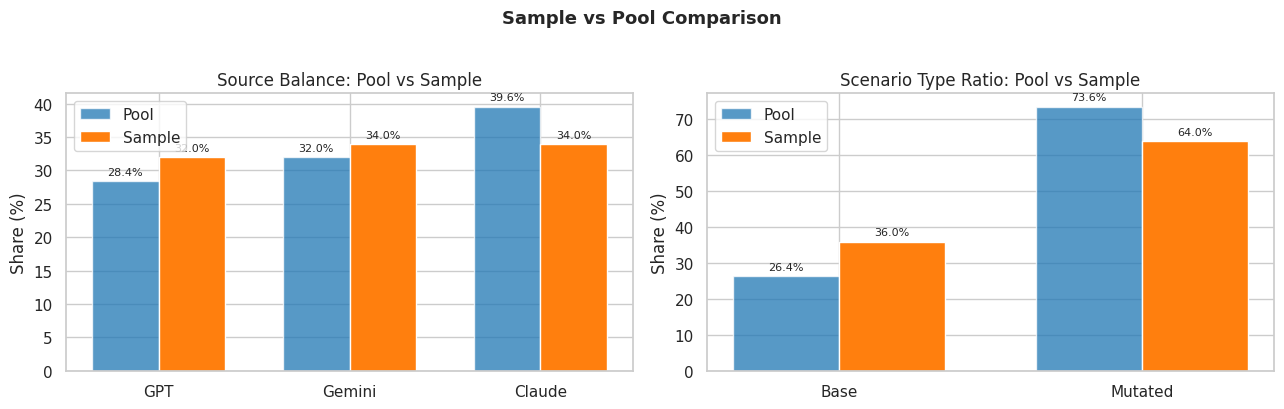


Domain coverage: 10/10 pool domains present in sample
  All pool domains represented in sample.


In [15]:
# ── SAMPLE vs POOL COMPARISON ─────────────────────────────────
if not POOL_SOURCE_MAP:
    print("POOL_SOURCE_MAP is empty — skipping pool comparison.")
else:
    pool_records = []
    for version, src_label in POOL_SOURCE_MAP.items():
        path = Path(POOL_DATASET_ROOT) / version / "final" / "scenarios.jsonl"
        if not path.exists():
            print(f"  ⚠ Pool file not found: {path} — skipping source {src_label}")
            continue
        with open(path, encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    row = json.loads(line)
                    row["_pool_source"] = src_label
                    pool_records.append(row)
    pool = pd.DataFrame(pool_records)
    pool["is_base"] = pool["mutation_trace"].apply(lambda x: len(x.get("mutations", [])) == 0)
    pool["domain"]  = pool["domain"]
    pool_total = len(pool)

    print(f"Pool loaded: {pool_total} scenarios")
    print(f"Sample     : {total} scenarios (sampling rate: {total / pool_total * 100:.1f}%)")

    # ── Source balance comparison ──
    pool_src_pct  = pool.groupby("_pool_source").size() / pool_total * 100
    sample_src_pct = source_pcts.copy()

    x = np.arange(len(SOURCE_ORDER))
    width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Source balance
    ax = axes[0]
    pool_vals   = [pool_src_pct.get(s, 0) for s in SOURCE_ORDER]
    sample_vals = [sample_src_pct.get(s, 0) for s in SOURCE_ORDER]
    bars1 = ax.bar(x - width / 2, pool_vals,   width, label="Pool",   color=COLORS[0], alpha=0.75)
    bars2 = ax.bar(x + width / 2, sample_vals, width, label="Sample", color=COLORS[1])
    ax.bar_label(bars1, fmt="%.1f%%", padding=3, fontsize=8)
    ax.bar_label(bars2, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([SOURCE_LABELS[s] for s in SOURCE_ORDER])
    ax.set_ylabel("Share (%)")
    ax.set_title("Source Balance: Pool vs Sample")
    ax.legend()

    # Base/Mutated ratio
    ax = axes[1]
    pool_base_pct   = pool["is_base"].mean() * 100
    sample_base_pct = df["is_base"].mean() * 100
    categories = ["Base", "Mutated"]
    pool_vals2   = [pool_base_pct,   100 - pool_base_pct]
    sample_vals2 = [sample_base_pct, 100 - sample_base_pct]
    x2 = np.arange(2)
    bars1 = ax.bar(x2 - width / 2, pool_vals2,   width, label="Pool",   color=COLORS[0], alpha=0.75)
    bars2 = ax.bar(x2 + width / 2, sample_vals2, width, label="Sample", color=COLORS[1])
    ax.bar_label(bars1, fmt="%.1f%%", padding=3, fontsize=8)
    ax.bar_label(bars2, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set_xticks(x2)
    ax.set_xticklabels(categories)
    ax.set_ylabel("Share (%)")
    ax.set_title("Scenario Type Ratio: Pool vs Sample")
    ax.legend()

    plt.suptitle("Sample vs Pool Comparison", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # ── Domain coverage ──
    pool_domains   = set(pool["domain"].unique())
    sample_domains = set(df["domain"].unique())
    covered_domains = sample_domains & pool_domains
    print(f"\nDomain coverage: {len(covered_domains)}/{len(pool_domains)} pool domains present in sample")
    missing_dom = pool_domains - sample_domains
    if missing_dom:
        print(f"  Domains not sampled: {sorted(missing_dom)}")
    else:
        print("  All pool domains represented in sample.")

## Section 13 — Post-Sampling Summary

Automated readiness report combining audit results with additional structural checks.

In [16]:
# ── POST-SAMPLING SUMMARY ─────────────────────────────────────
print("=" * 58)
print("  POST-SAMPLING SUMMARY")
print("=" * 58)

issues   = []   # blockers
warnings = []   # soft issues

# ── Audit hard checks ──────────────────────────────────────────
print("\n[Audit — Hard Checks]")
hard_checks = ["source_balance", "obligation_coverage", "sample_size", "id_uniqueness"]
for chk in hard_checks:
    passed = audit[chk]["pass"]
    symbol = "✓" if passed else "✗"
    print(f"  {symbol} {chk}")
    if not passed:
        issues.append(f"HARD FAIL: {chk}")

# ── Audit soft check ──────────────────────────────────────────
print("\n[Audit — Soft Check]")
dc = audit["dimension_coverage"]
if dc["pass"]:
    print("  ✓ dimension_coverage")
else:
    print(f"  ⚠ dimension_coverage — missing: {dc['missing_dimensions']}")
    warnings.append(f"Missing dimensions: {dc['missing_dimensions']}")

# ── Structural checks ─────────────────────────────────────────
print("\n[Structural Checks]")

# ID uniqueness (double-check in sample)
dup_ids = df[df.duplicated("scenario_id", keep=False)]["scenario_id"].unique()
if len(dup_ids) == 0:
    print(f"  ✓ No duplicate scenario_ids ({total} unique)")
else:
    print(f"  ✗ Duplicate scenario_ids found: {list(dup_ids[:5])}")
    issues.append(f"Duplicate scenario_ids: {list(dup_ids)}")

# Null fields
KEY_FIELDS = ["scenario_id", "source", "obligation_id", "scenario_type", "primary_dimension", "mutation_type", "prompt"]
null_any = False
for field in KEY_FIELDS:
    null_count = df[field].isna().sum() if field in df.columns else total
    if null_count > 0:
        print(f"  ⚠ Null values in '{field}': {null_count}")
        warnings.append(f"Null values in '{field}': {null_count}")
        null_any = True
if not null_any:
    print("  ✓ No null values in required sampler fields")

# Phase-1 scenarios present
missing_p1 = [sid for sid in coverage_map.values() if sid not in set(df["scenario_id"])]
if missing_p1:
    print(f"  ✗ {len(missing_p1)} Phase-1 scenario(s) missing from sample")
    issues.append(f"Phase-1 scenarios missing: {missing_p1}")
else:
    print(f"  ✓ All {len(coverage_map)} Phase-1 scenarios present")

# Domain diversity
n_domains = df["domain"].nunique()
if n_domains >= 5:
    print(f"  ✓ Domain diversity: {n_domains} unique domains")
else:
    print(f"  ⚠ Low domain diversity: only {n_domains} unique domain(s)")
    warnings.append(f"Low domain diversity: {n_domains} domains")

# ── Snapshot ──────────────────────────────────────────────────
print("\n" + "─" * 58)
print("SAMPLE SNAPSHOT")
print("─" * 58)
p1_n = manifest["phase1"]["scenarios_drawn"]
p2_n = manifest["phase2"]["scenarios_drawn"]
print(f"  Total scenarios  : {total} (target: {manifest['target_n']})")
print(f"  Phase 1          : {p1_n} ({p1_n / total * 100:.1f}%) — obligation coverage")
print(f"  Phase 2          : {p2_n} ({p2_n / total * 100:.1f}%) — source-balanced fill")
print(f"  Base / Mutated   : {int(df['is_base'].sum())} / {int((~df['is_base']).sum())}")
print(f"  Unique domains   : {n_domains}")
print(f"  Obligations cov. : {len(coverage_map)}")

print()
if issues:
    print(f"✗ {len(issues)} BLOCKER(S) — sample should not proceed to inference:")
    for issue in issues:
        print(f"     • {issue}")
elif warnings:
    print(f"⚠ {len(warnings)} warning(s) — review before proceeding:")
    for w in warnings:
        print(f"     • {w}")
    print("\n✓ Sample is ready for inference (no hard blockers).")
else:
    print("✓ All checks passed — sample is ready for inference.")

  POST-SAMPLING SUMMARY

[Audit — Hard Checks]
  ✓ source_balance
  ✓ obligation_coverage
  ✓ sample_size
  ✓ id_uniqueness

[Audit — Soft Check]
  ⚠ dimension_coverage — missing: ['accountability']

[Structural Checks]
  ✓ No duplicate scenario_ids (50 unique)
  ⚠ Null values in 'mutation_type': 18
  ✓ All 30 Phase-1 scenarios present
  ✓ Domain diversity: 10 unique domains

──────────────────────────────────────────────────────────
SAMPLE SNAPSHOT
──────────────────────────────────────────────────────────
  Total scenarios  : 50 (target: 50)
  Phase 1          : 30 (60.0%) — obligation coverage
  Phase 2          : 20 (40.0%) — source-balanced fill
  Base / Mutated   : 18 / 32
  Unique domains   : 10
  Obligations cov. : 30

⚠ 2 warning(s) — review before proceeding:
     • Missing dimensions: ['accountability']
     • Null values in 'mutation_type': 18

✓ Sample is ready for inference (no hard blockers).
